In [1]:
# Variables
DATASET_PATH = 'flwrlabs/fed-isic2019'
LABELS = list(map(str, range(8)))
GROUP_COL = 'center'

In [ ]:
# import sys
# import os
# sys.path.append(os.path.join('..', 'densenet-pytorch'))
# from densenet import DenseNet3
# model = DenseNet3(12, len(LABELS), 12, reduction=1.0, bottleneck=False, dropRate=0.4)


In [5]:
import eda_helpers as eda
model = eda.models.efficientnet_b3(weights="DEFAULT")
# model.classifier = eda.nn.Linear(model.classifier.in_features, len(LABELS))

model.load_state_dict(eda.torch.load('/home/kpetrenko/work/models/skin'))


<All keys matched successfully>

In [11]:
list(map(lambda x: x[0], model.named_parameters()))

['features.conv0.weight',
 'features.norm0.weight',
 'features.norm0.bias',
 'features.denseblock1.denselayer1.norm1.weight',
 'features.denseblock1.denselayer1.norm1.bias',
 'features.denseblock1.denselayer1.conv1.weight',
 'features.denseblock1.denselayer1.norm2.weight',
 'features.denseblock1.denselayer1.norm2.bias',
 'features.denseblock1.denselayer1.conv2.weight',
 'features.denseblock1.denselayer2.norm1.weight',
 'features.denseblock1.denselayer2.norm1.bias',
 'features.denseblock1.denselayer2.conv1.weight',
 'features.denseblock1.denselayer2.norm2.weight',
 'features.denseblock1.denselayer2.norm2.bias',
 'features.denseblock1.denselayer2.conv2.weight',
 'features.denseblock1.denselayer3.norm1.weight',
 'features.denseblock1.denselayer3.norm1.bias',
 'features.denseblock1.denselayer3.conv1.weight',
 'features.denseblock1.denselayer3.norm2.weight',
 'features.denseblock1.denselayer3.norm2.bias',
 'features.denseblock1.denselayer3.conv2.weight',
 'features.denseblock1.denselayer4.n

In [10]:
list(model.features.children())[:10]

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 _DenseBlock(
   (denselayer1): _DenseLayer(
     (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu1): ReLU(inplace=True)
     (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
     (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu2): ReLU(inplace=True)
     (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   )
   (denselayer2): _DenseLayer(
     (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu1): ReLU(inplace=True)
     (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
     (norm2): BatchNorm2d(128, 

In [13]:
import importlib

importlib.reload(eda)


<module 'eda_helpers' from '/home/kpetrenko/work/third_attempt/EDA/eda_helpers.py'>

In [6]:
transform = eda.transforms.Compose([
        eda.transforms.ToTensor(),
        eda.transforms.Normalize(mean=[0.479, 0.455, 0.461], std=[0.109, 0.104, 0.105])
    ])
import psutil
device = eda.torch.device('cpu')
eda.torch.set_num_threads(min(20, psutil.cpu_count()))

correct per cent:  0.6503225806451612


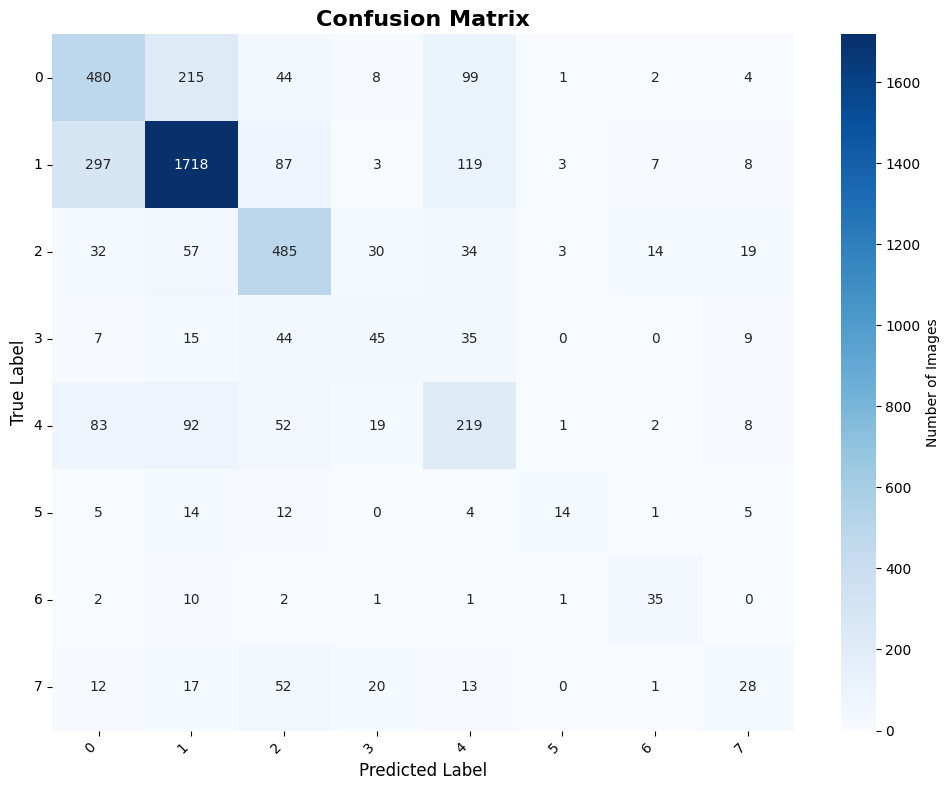

array([[ 480,  215,   44,    8,   99,    1,    2,    4],
       [ 297, 1718,   87,    3,  119,    3,    7,    8],
       [  32,   57,  485,   30,   34,    3,   14,   19],
       [   7,   15,   44,   45,   35,    0,    0,    9],
       [  83,   92,   52,   19,  219,    1,    2,    8],
       [   5,   14,   12,    0,    4,   14,    1,    5],
       [   2,   10,    2,    1,    1,    1,   35,    0],
       [  12,   17,   52,   20,   13,    0,    1,   28]])

In [ ]:
data_test = eda.download_dataset(DATASET_PATH, 'test')
data_test['image'] = data_test['image'].map(lambda x: eda.resize_and_pad(x, (128, 128)))

val_test = eda.DataFrameImageDataset(data_test, "image", "label", transform)
val_loader = eda.DataLoader(val_test, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
predictions, targets, probabilities = eda.evaluate_model(model, val_loader, device)
cm = eda.plot_confusion_matrix(targets, predictions, LABELS)
display(cm)
# 0.72 new (30 epoches) vs 0.698 old (15 epochs)
# efficient - 0.65 (15 epoch)

In [ ]:
eda.visualize_errors(data_test, targets, predictions, probabilities, LABELS)

In [7]:
# DOMAIN = data_test.center.unique()
# for domain in DOMAIN:
#     print(domain, end=':\n')
#     val_test = eda.DataFrameImageDataset(data_test[data_test[GROUP_COL] == domain], "image", "label", transform)
#     val_loader = eda.DataLoader(val_test, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)
    
    
#     predictions, targets, probabilities = eda.evaluate_model(model, val_loader, device)
#     cm = eda.plot_confusion_matrix(targets, predictions, LABELS)
#     display(cm)

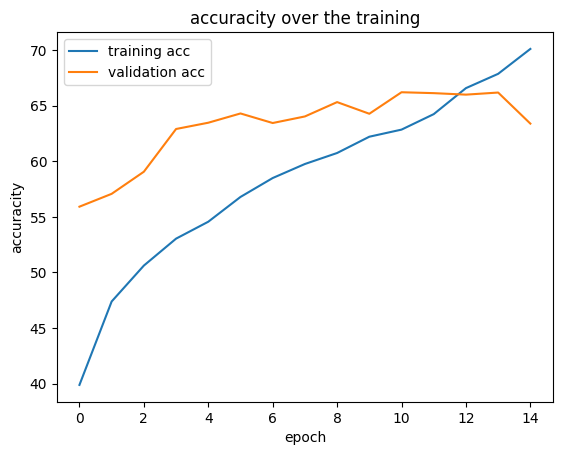

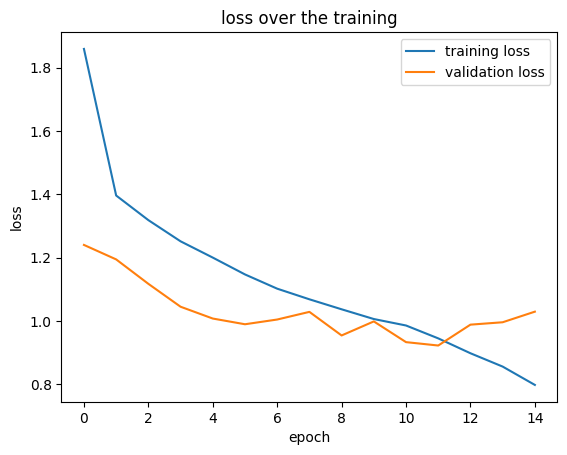

In [3]:
import json
with open("/home/kpetrenko/work/models/skin_progress", 'r') as f:
    training_acc = json.loads(f.readline())

    validation_acc =  json.loads(f.readline())

    training_loss = json.loads(f.readline())

    validation_loss = json.loads(f.readline())


eda.draw_model_training_process(training_acc, validation_acc, training_loss, validation_loss)

In [5]:
data = eda.download_dataset(DATASET_PATH, 'train')
data['image'] = data['image'].map(lambda x: eda.resize_and_pad(x, (128, 128)))

In [6]:

import albumentations as alb
augmentation = alb.Compose([
            alb.Affine(
                translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
                rotate=(-170, 170),
                p=1),
            alb.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.2, hue=0,
                p=0.9
            )
            ])
transform = lambda x: x
train_df, val_df = eda.train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
train_dataset = eda.DataFrameImageDataset(train_df, 'image', 'label', transform, augemntation_pipeline=augmentation, consider_small=2000, consider_mild=6000)


In [ ]:
fig, axes = eda.plt.subplots(nrows=5, ncols=5, figsize=(20, 60))
axes = axes.flatten()
axes_ind = 0
for group in range(25):
    ax = axes[axes_ind]
    
    imgs = train_dataset[axes_ind][0]
    ax.imshow(imgs)
    ax.axis('off')
    axes_ind += 1
eda.plt.show()
eda.plt.close(fig)

In [ ]:
val_dataset = eda.DataFrameImageDataset(val_df, 'image', 'label', transform)

fig, axes = eda.plt.subplots(nrows=5, ncols=5, figsize=(20, 60))
axes = axes.flatten()
axes_ind = 0
for group in range(25):
    ax = axes[axes_ind]
    
    imgs = val_dataset[axes_ind][0] #.permute(1, 2, 0) 
    ax.imshow(imgs)
    ax.axis('off')
    axes_ind += 1
eda.plt.show()
eda.plt.close(fig)